<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq

In [1]:
from fastai.vision.all import *

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [2]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=parent_label,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

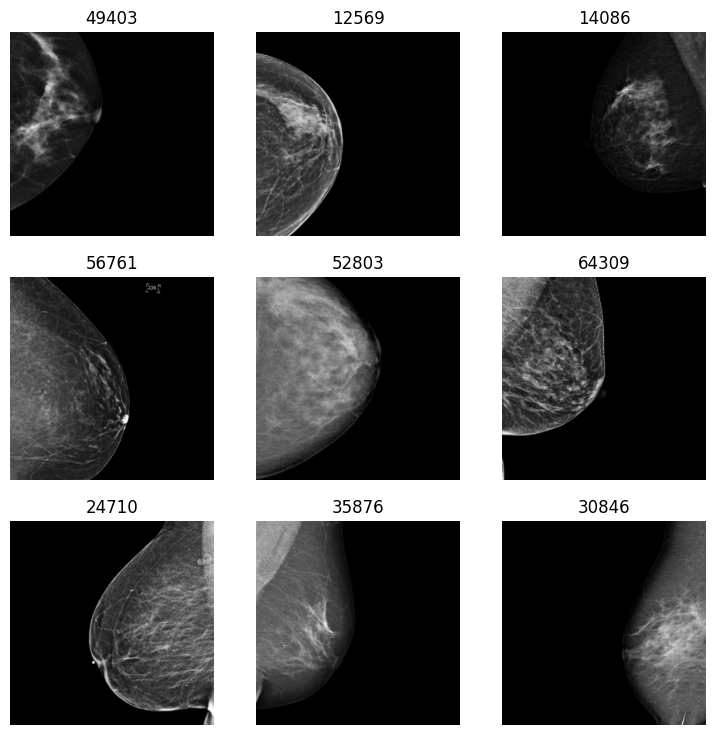

In [3]:
dls = db.dataloaders(imagesPath, bs=128)
dls.show_batch()

In [4]:
callbacks = [
    MixUp(),
    ShowGraphCallback(),
    EarlyStoppingCallback(patience=3),
    SaveModelCallback(fname='modelResnet18')  
]

In [5]:
learn = vision_learner(dls, resnet18, metrics=accuracy, cbs=callbacks, loss_func=LabelSmoothingCrossEntropy()).to_fp16()

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


SuggestedLRs(valley=0.007585775572806597)

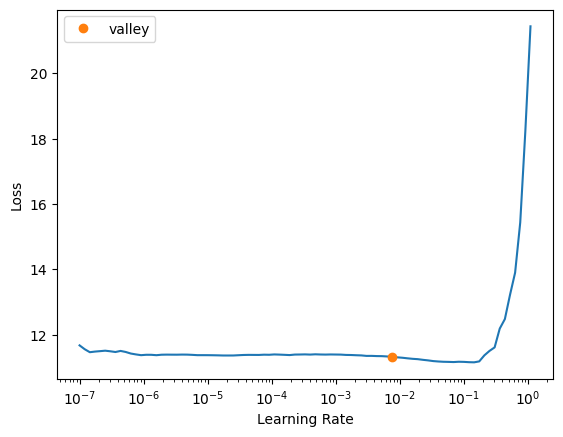

In [6]:
learn.lr_find()

In [7]:
learn.fit_one_cycle(2, 1e-2)
learn.unfreeze()
learn.fit_one_cycle(3, lr_max=slice(1e-5,1e-3))

epoch,train_loss,valid_loss,accuracy,time


KeyError: ignored

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=parent_label,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=424,min_scale=0.75))

In [ ]:
learn.dls = db.dataloaders(imagesPath, bs=256)
learn.fine_tune(5, base_lr=1e-2)

In [ ]:
learn.validate()

In [ ]:
preds, targs = learn.tta()
accuracy(preds, targs).item()